In [ ]:
sensitive_features_list = ["Gender", "Property_Area", "Education", "Married"]

In [ ]:
!pip install fairlearn

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/train (2).csv")

target = input("Enter target column: ")
sensitive_features = input("Enter sensitive columns (comma separated): ").split(",")

sensitive_features = [col.strip() for col in sensitive_features if col.strip() in df.columns]

print("Target:", target)
print("Sensitive Features:", sensitive_features)

Enter target column: Loan_Status
Enter sensitive columns (comma separated): Gender,Property_Area,Education,Married
Target: Loan_Status
Sensitive Features: ['Gender', 'Property_Area', 'Education', 'Married']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df[target] = le.fit_transform(df[target])

print("Target column after Label Encoding:")
print(df[target].head())

# (optional) to see mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", mapping)

Target column after Label Encoding:
0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64
Class mapping: {'N': np.int64(0), 'Y': np.int64(1)}


In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
X = df.drop(columns=[target])
y = df[target]

X_fair = X.copy()  # 🔥 important for fairness

In [ ]:
print("\n📊 DATA-LEVEL BIAS CHECK")

for col in sensitive_features:
    print(f"\n🔍 {col} Distribution:")
    print(X[col].value_counts(normalize=True))


📊 DATA-LEVEL BIAS CHECK

🔍 Gender Distribution:
Gender
Male      0.81759
Female    0.18241
Name: proportion, dtype: float64

🔍 Property_Area Distribution:
Property_Area
Semiurban    0.379479
Urban        0.328990
Rural        0.291531
Name: proportion, dtype: float64

🔍 Education Distribution:
Education
Graduate        0.781759
Not Graduate    0.218241
Name: proportion, dtype: float64

🔍 Married Distribution:
Married
Yes    0.653094
No     0.346906
Name: proportion, dtype: float64


In [ ]:
# Create weights for balancing groups
weights = np.ones(len(X))

for col in sensitive_features:
    freq = X[col].value_counts(normalize=True)
    weights *= X[col].map(lambda x: 1 / freq[x])

weights = weights / np.mean(weights)

print("\n✅ Sample weights created")


✅ Sample weights created


In [ ]:
print("\n📊 DATA FAIRNESS CHECK (Before vs After Reweighting)")

for col in sensitive_features:
    print(f"\n🔍 Feature: {col}")

    # BEFORE (original distribution)
    before_dist = X[col].value_counts(normalize=True)

    # AFTER (weighted distribution)
    after_dist = (
        X.groupby(col)
         .apply(lambda g: weights[g.index].sum())
    )
    after_dist = after_dist / after_dist.sum()

    df_compare = pd.DataFrame({
        "Before": before_dist,
        "After (Weighted)": after_dist
    }).fillna(0)

    print(df_compare)


📊 DATA FAIRNESS CHECK (Before vs After Reweighting)

🔍 Feature: Gender
         Before  After (Weighted)
Gender                           
Female  0.18241          0.540706
Male    0.81759          0.459294

🔍 Feature: Property_Area
                 Before  After (Weighted)
Property_Area                            
Rural          0.291531          0.329767
Semiurban      0.379479          0.362681
Urban          0.328990          0.307552

🔍 Feature: Education
                Before  After (Weighted)
Education                               
Graduate      0.781759          0.525074
Not Graduate  0.218241          0.474926

🔍 Feature: Married
           Before  After (Weighted)
Married                            
No       0.346906          0.634772
Yes      0.653094          0.365228


/tmp/ipykernel_5455/2622352570.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weights[g.index].sum())
/tmp/ipykernel_5455/2622352570.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weights[g.index].sum())
/tmp/ipykernel_5455/2622352570.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 🔥 AUTO-DETECT USELESS COLUMNS
def detect_useless_columns(df):
    useless_cols = []

    for col in df.columns:
        # 1. ID-like columns (unique values ≈ number of rows)
        if df[col].nunique() == len(df):
            useless_cols.append(col)

        # 2. Constant columns
        elif df[col].nunique() == 1:
            useless_cols.append(col)

    return useless_cols


# Apply AFTER split (only on train → avoid leakage)
useless_cols = detect_useless_columns(X_train)

print("🚫 Removing columns:", useless_cols)

# Drop from both train and test
X_train = X_train.drop(columns=useless_cols)
X_test = X_test.drop(columns=useless_cols)

🚫 Removing columns: ['Loan_ID']


In [ ]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

print("✅ Encoding Done:", X_train.shape)

✅ Encoding Done: (491, 20)


In [ ]:
print("Class Distribution:")
print(y_train.value_counts(normalize=True))

Class Distribution:
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64


In [ ]:
imbalance_ratio = y_train.value_counts(normalize=True).min()

if imbalance_ratio < 0.25:
    strategy = "SMOTE"
elif imbalance_ratio < 0.40:
    strategy = "BOTH"   # 🔥 this is your case
else:
    strategy = "NO_SMOTE"

print("Selected Strategy:", strategy)

Selected Strategy: BOTH


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train, sample_weight=w_train)

y_pred_no_smote = rf.predict(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone

def smote_decision_pipeline(model, X_train, y_train, X_test, y_test):

    print("\n🚀 SMOTE DECISION PIPELINE")
    print("="*50)

    # -------------------------------
    # WITHOUT SMOTE
    # -------------------------------
    model_no = clone(model)
    model_no.fit(X_train, y_train)

    y_pred_no = model_no.predict(X_test)

    acc_no = accuracy_score(y_test, y_pred_no)
    f1_no = f1_score(y_test, y_pred_no, average='weighted')

    print("\nWITHOUT SMOTE")
    print("Accuracy:", acc_no)
    print("F1 Score:", f1_no)

    # -------------------------------
    # WITH SMOTE
    # -------------------------------
    smote = SMOTE(random_state=42)

    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    model_sm = clone(model)
    model_sm.fit(X_train_sm, y_train_sm)

    y_pred_sm = model_sm.predict(X_test)

    acc_sm = accuracy_score(y_test, y_pred_sm)
    f1_sm = f1_score(y_test, y_pred_sm, average='weighted')

    print("\nWITH SMOTE")
    print("Accuracy:", acc_sm)
    print("F1 Score:", f1_sm)

    # -------------------------------
    # DECISION LOGIC
    # -------------------------------
    print("\n📊 COMPARISON")

    if (f1_sm > f1_no) and (acc_sm >= acc_no - 0.02):
        print("✅ Using SMOTE dataset")
        return X_train_sm, y_train_sm, "SMOTE"

    else:
        print("✅ Using ORIGINAL dataset")
        return X_train, y_train, "ORIGINAL"

In [ ]:
X_train_final_smote, y_train_final_smote, choice = smote_decision_pipeline(
    model=rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

print("\n🔥 FINAL CHOICE:", choice)


🚀 SMOTE DECISION PIPELINE

WITHOUT SMOTE
Accuracy: 0.8373983739837398
F1 Score: 0.8275149647100867

WITH SMOTE
Accuracy: 0.8130081300813008
F1 Score: 0.8051498875699171

📊 COMPARISON
✅ Using ORIGINAL dataset

🔥 FINAL CHOICE: ORIGINAL


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance


# 🔹 Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "f1": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }


# 🔥 GENERALIZED FEATURE SELECTION PIPELINE
def full_feature_selection_pipeline(model, X_train, y_train, X_test, y_test,
                                    corr_threshold=0.9,
                                    tolerance=0.10):

    print("\n" + "="*75)
    print("🚀 GENERALIZED FEATURE SELECTION PIPELINE")
    print("="*75)

    # =========================================================
    # 🔹 STEP 1: FEATURE IMPORTANCE
    # =========================================================
    print("\n🔍 Calculating Feature Importance...")

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])

    else:
        print("⚠️ Using Permutation Importance")
        perm = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
        importances = perm.importances_mean

    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print("\n🔹 Top Features:")
    print(importance_df.head(10).to_string(index=False))

    # =========================================================
    # 🔹 STEP 2: DYNAMIC THRESHOLDS
    # =========================================================
    mean_imp = importance_df['Importance'].mean()
    std_imp = importance_df['Importance'].std()

    low_threshold = mean_imp * 0.5
    high_threshold = mean_imp + std_imp

    # =========================================================
    # 🔹 STEP 3: SELECT FEATURES TO DROP
    # =========================================================
    removal_reason = {}

    for _, row in importance_df.iterrows():
        f = row['Feature']
        imp = row['Importance']

        if imp < low_threshold:
            removal_reason[f] = "Low Importance"
        elif imp > high_threshold:
            removal_reason[f] = "Dominant"

    # =========================================================
    # 🔹 STEP 4: CORRELATION CHECK
    # =========================================================
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    for col in upper.columns:
        if any(upper[col] > corr_threshold):
            removal_reason[col] = "High Correlation"

    drop_features = list(removal_reason.keys())

    print("\n🗑️ Feature Removal Summary:")
    for f, r in removal_reason.items():
        print(f"{f:<20} → {r}")

    print(f"\n❌ Total Features Removed: {len(drop_features)}")

    # =========================================================
    # 🔹 STEP 5: BASELINE METRICS
    # =========================================================
    base_metrics = evaluate_model(model, X_test, y_test)

    print("\n📊 Baseline Metrics:")
    for k, v in base_metrics.items():
        print(f"{k:<10}: {v:.4f}")

    # =========================================================
    # 🔹 STEP 6: REMOVE FEATURES
    # =========================================================
    X_train_new = X_train.drop(columns=drop_features, errors='ignore')
    X_test_new = X_test.drop(columns=drop_features, errors='ignore')

    if X_train_new.shape[1] < 2:
        print("\n⚠️ Too many features removed — reverting")
        return X_train, X_test

    # =========================================================
    # 🔹 STEP 7: RETRAIN MODEL
    # =========================================================
    new_model = clone(model)
    new_model.fit(X_train_new, y_train)

    new_metrics = evaluate_model(new_model, X_test_new, y_test)

    # =========================================================
    # 🔹 STEP 8: METRIC COMPARISON
    # =========================================================
    comparison_df = pd.DataFrame({
        "Metric": list(base_metrics.keys()),
        "Before": list(base_metrics.values()),
        "After": list(new_metrics.values())
    })

    comparison_df["Drop"] = comparison_df["Before"] - comparison_df["After"]

    print("\n📊 METRIC COMPARISON:")
    print(comparison_df.to_string(index=False))

    # =========================================================
    # 🔹 STEP 9: DECISION LOGIC
    # =========================================================
    decision_flag = True

    for _, row in comparison_df.iterrows():
        if row["Drop"] > tolerance:
            decision_flag = False

    # =========================================================
    # 🔹 STEP 10: SHAP
    # =========================================================
    print("\n🧠 SHAP Explainability...")

    try:
        sample_X = X_test_new.sample(min(100, len(X_test_new)), random_state=42)

        if hasattr(new_model, "feature_importances_"):
            explainer = shap.TreeExplainer(new_model)
        else:
            explainer = shap.Explainer(new_model, sample_X)

        shap_values = explainer(sample_X)
        shap.summary_plot(shap_values, sample_X)

    except Exception as e:
        print("⚠️ SHAP skipped:", e)

    # =========================================================
    # 🔹 FINAL DECISION
    # =========================================================
    if decision_flag:
        print("\n✅ FINAL: Optimized dataset selected")
        final_X_train = X_train_new
        final_X_test = X_test_new
    else:
        print("\n⚠️ FINAL: Keeping original dataset")
        final_X_train = X_train
        final_X_test = X_test

    # =========================================================
    # 🔹 FINAL HEATMAP
    # =========================================================
    print("\n📊 Final Feature Correlation Heatmap...")

    try:
        features = final_X_train.columns[:15]

        plt.figure(figsize=(10, 6))
        sns.heatmap(
            final_X_train[features].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )
        plt.title("Final Dataset Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("⚠️ Heatmap skipped:", e)

    return final_X_train, final_X_test


🚀 GENERALIZED FEATURE SELECTION PIPELINE

🔍 Calculating Feature Importance...

🔹 Top Features:
                     Feature  Importance
   remainder__Credit_History    0.245785
       remainder__LoanAmount    0.177603
  remainder__ApplicantIncome    0.164866
remainder__CoapplicantIncome    0.076247
 remainder__Loan_Amount_Term    0.057939
     cat__Education_Graduate    0.027023
cat__Property_Area_Semiurban    0.025642
 cat__Education_Not Graduate    0.024842
    cat__Property_Area_Rural    0.023159
          cat__Gender_Female    0.020078

🗑️ Feature Removal Summary:
remainder__Credit_History → Dominant
remainder__LoanAmount → Dominant
remainder__ApplicantIncome → Dominant
cat__Education_Not Graduate → High Correlation
cat__Property_Area_Rural → Low Importance
cat__Gender_Female   → Low Importance
cat__Property_Area_Urban → Low Importance
cat__Gender_Male     → High Correlation
cat__Married_No      → Low Importance
cat__Dependents_0    → Low Importance
cat__Married_Yes     → High Cor

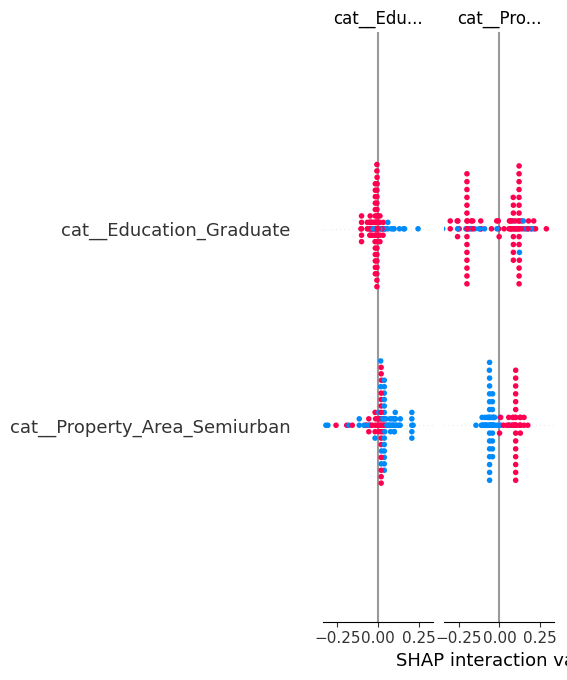


⚠️ FINAL: Keeping original dataset

📊 Final Feature Correlation Heatmap...


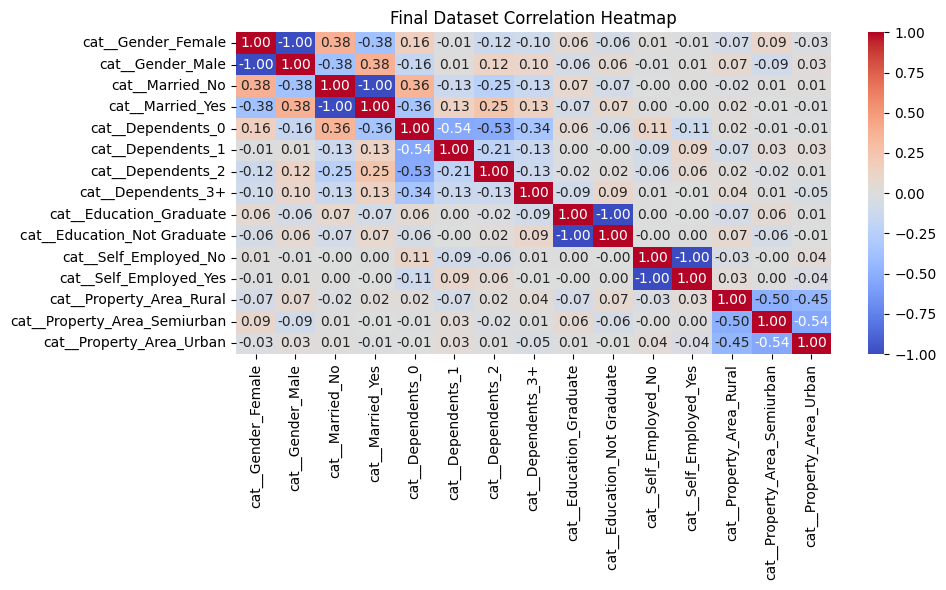

In [ ]:
x_train_final, x_test_final = full_feature_selection_pipeline(
    model=rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

In [ ]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("\n" + "="*60)
print("🚀 FINAL MODEL TRAINING")
print("="*60)

# 🔹 Clone base model
final_model = clone(rf)

# 🔹 Train using selected data (SMOTE or ORIGINAL automatically)
final_model.fit(x_train_final, y_train_final_smote)

# 🔹 Predict
y_pred_final = final_model.predict(x_test_final)

# =========================================================
# 🔹 FINAL METRICS
# =========================================================
print("\n📊 FINAL MODEL PERFORMANCE")

accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_final, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_final, average='weighted', zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n📄 Classification Report")
print(classification_report(y_test, y_pred_final))

# 🔥 Check which data was used
print("\n🔥 DATA USED FOR TRAINING:", choice)


🚀 FINAL MODEL TRAINING

📊 FINAL MODEL PERFORMANCE
Accuracy : 0.8374
Precision: 0.8385
Recall   : 0.8374
F1 Score : 0.8275

📄 Classification Report
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        38
           1       0.84      0.95      0.89        85

    accuracy                           0.84       123
   macro avg       0.84      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123


🔥 DATA USED FOR TRAINING: ORIGINAL


In [ ]:
sensitive_features = ["Gender", "Property_Area", "Education", "Married"]

# Keep only available ones
sensitive_features = [col for col in sensitive_features if col in X.columns]

print("Sensitive Features:", sensitive_features)

Sensitive Features: ['Gender', 'Property_Area', 'Education', 'Married']


In [ ]:
!pip install fairlearn

In [ ]:
y_pred_final

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0])

In [ ]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference
)

print("\n" + "="*60)
print("📊 FINAL FAIRNESS ANALYSIS")
print("="*60)

fairness_results = []

for feature in sensitive_features:

    print(f"\n🔍 Feature: {feature}")

    sf_test = X.loc[y_test.index, feature]

    # MetricFrame
    mf = MetricFrame(
        metrics={
            "accuracy": accuracy_score,
            "selection_rate": selection_rate
        },
        y_true=y_test,
        y_pred=y_pred_final,
        sensitive_features=sf_test
    )

    print("\nGroup-wise Metrics:")
    print(mf.by_group)

    # Fairness metrics
    eo = equalized_odds_difference(
        y_test, y_pred_final,
        sensitive_features=sf_test
    )

    dp = demographic_parity_difference(
        y_test, y_pred_final,
        sensitive_features=sf_test
    )

    print(f"\nEO Difference: {eo:.4f}")
    print(f"DP Difference: {dp:.4f}")

    fairness_results.append({
        "Feature": feature,
        "EO": eo,
        "DP": dp,
        "Score": (abs(eo) + abs(dp)) / 2
    })


📊 FINAL FAIRNESS ANALYSIS

🔍 Feature: Gender

Group-wise Metrics:
        accuracy  selection_rate
Gender                          
Female  0.800000        0.680000
Male    0.846939        0.816327

EO Difference: 0.0808
DP Difference: 0.1363

🔍 Feature: Property_Area

Group-wise Metrics:
               accuracy  selection_rate
Property_Area                          
Rural          0.647059        0.823529
Semiurban      0.959184        0.775510
Urban          0.850000        0.775000

EO Difference: 0.5962
DP Difference: 0.0485

🔍 Feature: Education

Group-wise Metrics:
              accuracy  selection_rate
Education                             
Graduate      0.850000        0.820000
Not Graduate  0.782609        0.652174

EO Difference: 0.1149
DP Difference: 0.1678

🔍 Feature: Married

Group-wise Metrics:
         accuracy  selection_rate
Married                          
No       0.750000        0.636364
Yes      0.886076        0.873418

EO Difference: 0.1600
DP Difference: 0.237

In [ ]:
fairness_df = pd.DataFrame(fairness_results).sort_values(by="Score", ascending=False)

print("\n📊 FINAL BIAS RANKING:")
print(fairness_df)


📊 FINAL BIAS RANKING:
         Feature        EO        DP     Score
1  Property_Area  0.596154  0.048529  0.322342
3        Married  0.160000  0.237054  0.198527
2      Education  0.114943  0.167826  0.141384
0         Gender  0.080808  0.136327  0.108567


In [ ]:
print("\n📌 INTERPRETATION + NEXT STEPS:\n")

for _, row in fairness_df.iterrows():

    feature = row["Feature"]

    if row["Score"] > 0.3:
        level = "🔴 HIGH BIAS"
        suggestion = "Apply post-processing (ThresholdOptimizer) or remove/transform this feature."

    elif row["Score"] > 0.15:
        level = "🟡 MODERATE BIAS"
        suggestion = "Try reweighting again, feature engineering, or check proxy bias."

    else:
        level = "🟢 LOW BIAS"
        suggestion = "Bias is acceptable, no major intervention needed."

    print(f"{feature}: {level}")
    print(f"   ➤ Suggested Action: {suggestion}\n")


📌 INTERPRETATION + NEXT STEPS:

Property_Area: 🔴 HIGH BIAS
   ➤ Suggested Action: Apply post-processing (ThresholdOptimizer) or remove/transform this feature.

Married: 🟡 MODERATE BIAS
   ➤ Suggested Action: Try reweighting again, feature engineering, or check proxy bias.

Education: 🟢 LOW BIAS
   ➤ Suggested Action: Bias is acceptable, no major intervention needed.

Gender: 🟢 LOW BIAS
   ➤ Suggested Action: Bias is acceptable, no major intervention needed.



In [ ]:
!pip install shap

In [ ]:
import shap

# Create explainer (works for most sklearn models)
explainer = shap.Explainer(final_model, X_train)

# Get SHAP values
shap_values = explainer(X_test)

 95%|=================== | 234/246 [00:16<00:00]       

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.Explainer(final_model, x_train_final)

# Get SHAP values
shap_values = explainer(x_test_final)

 92%|==================  | 226/246 [00:13<00:01]       

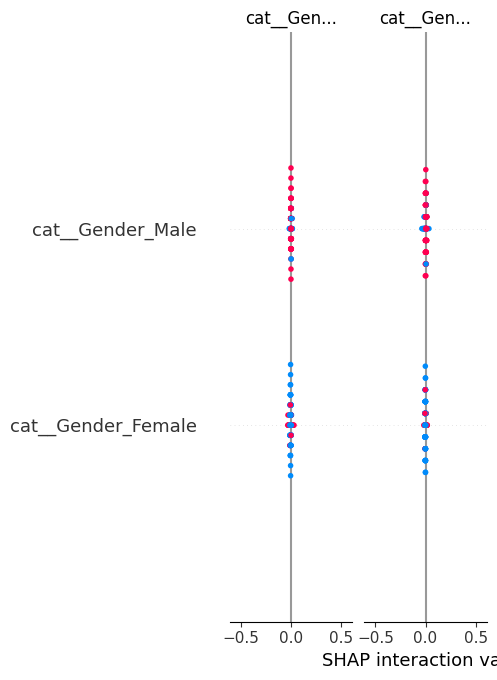

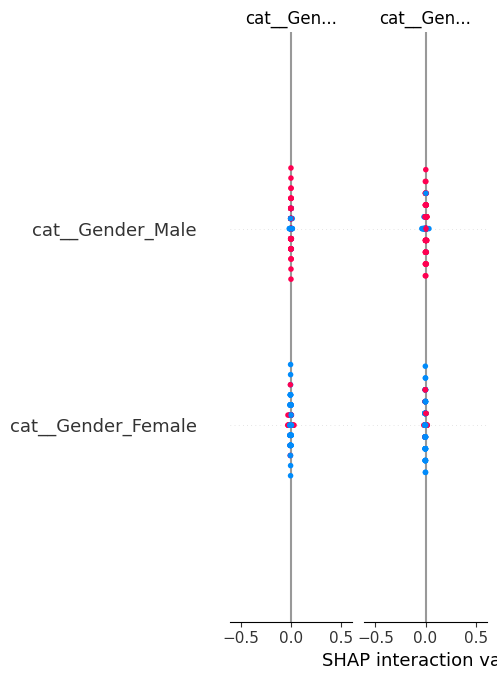

In [ ]:
# 1. Summary plot (most important - feature impact distribution)
shap.summary_plot(shap_values, x_test_final)

# 2. Bar plot (global feature importance)
shap.summary_plot(shap_values, x_test_final, plot_type="bar")

In [ ]:
print("\n📌 INTERPRETATION + NEXT STEPS + SHAP INSIGHT:\n")

# Mean SHAP importance
shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_feature_importance = dict(zip(X_test.columns, shap_importance))

# Percentile thresholds for SHAP
shap_values_list = list(shap_feature_importance.values())
p75 = np.percentile(shap_values_list, 75)
p40 = np.percentile(shap_values_list, 40)

for _, row in fairness_df.iterrows():

    feature = row["Feature"]
    score = row["Score"]

    shap_impact = shap_feature_importance.get(feature, 0)

    # SHAP level
    if shap_impact > p75:
        shap_level = "HIGH"
    elif shap_impact > p40:
        shap_level = "MODERATE"
    else:
        shap_level = "LOW"

    # Fairness level
    if score > 0.3:
        level = "🔴 HIGH BIAS"
        suggestion = "Apply ThresholdOptimizer or remove/transform feature."

    elif score > 0.15:
        level = "🟡 MODERATE BIAS"
        suggestion = "Reweight again, feature engineering, or check proxy bias."

    else:
        level = "🟢 LOW BIAS"
        suggestion = "Bias is acceptable."

    # Combined Insight
    if score > 0.3 and shap_level == "HIGH":
        insight = "⚠️ CRITICAL: Feature is both biased AND highly influential."
    elif score > 0.3 and shap_level == "LOW":
        insight = "⚠️ Bias exists but model does not rely heavily on this feature."
    elif score <= 0.15 and shap_level == "HIGH":
        insight = "ℹ️ Important feature but not causing fairness issue."
    else:
        insight = "✔ Balanced behavior."

    print(f"{feature}: {level}")
    print(f"   ➤ SHAP Impact: {shap_level}")
    print(f"   ➤ Suggested Action: {suggestion}")
    print(f"   ➤ Insight: {insight}\n")


📌 INTERPRETATION + NEXT STEPS + SHAP INSIGHT:

Property_Area: 🔴 HIGH BIAS
   ➤ SHAP Impact: LOW
   ➤ Suggested Action: Apply ThresholdOptimizer or remove/transform feature.
   ➤ Insight: ⚠️ Bias exists but model does not rely heavily on this feature.

Married: 🟡 MODERATE BIAS
   ➤ SHAP Impact: LOW
   ➤ Suggested Action: Reweight again, feature engineering, or check proxy bias.
   ➤ Insight: ✔ Balanced behavior.

Education: 🟢 LOW BIAS
   ➤ SHAP Impact: LOW
   ➤ Suggested Action: Bias is acceptable.
   ➤ Insight: ✔ Balanced behavior.

Gender: 🟢 LOW BIAS
   ➤ SHAP Impact: LOW
   ➤ Suggested Action: Bias is acceptable.
   ➤ Insight: ✔ Balanced behavior.



In [ ]:
# ================================
# FINAL DATASET EXPORT (CORRECT)
# ================================

# Since SMOTE NOT used → use original encoded data
final_X = x_train_final.copy()
final_y = y_train_final_smote.copy()  # still original since SMOTE not applied

final_df = final_X.copy()
final_df[target] = final_y

# OPTIONAL: include weights (VERY IMPORTANT 🔥)
final_df["sample_weight"] = w_train.loc[final_df.index]

final_df.to_csv("final_ml_dataset.csv", index=False)

print("✅ Final dataset saved: final_ml_dataset.csv")

✅ Final dataset saved: final_ml_dataset.csv


In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.8 MB/s eta 0:00:00


In [ ]:
# =========================
# SAVE HEATMAP IMAGE
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(x_train_final.corr(), cmap="coolwarm")
plt.title("Final Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.close()

# =========================
# SAVE SHAP IMAGE
# =========================
import shap

shap.summary_plot(shap_values, x_test_final, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png")
plt.close()

print("✅ Images saved")

✅ Images saved


In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
import pandas as pd

# ======================
# SAFE FAIRNESS TABLE FUNCTION
# ======================
def format_fairness_table(X, weights, sensitive_features):
    tables = []
    weight_series = pd.Series(weights, index=X.index)

    for col in sensitive_features:
        before = X[col].value_counts(normalize=True)

        after = weight_series.groupby(X[col]).sum()
        after = after / after.sum()

        df_compare = pd.DataFrame({
            "Before": before,
            "After": after
        }).fillna(0)

        table_str = f"<b>Feature: {col}</b><br/>"
        for idx, row in df_compare.iterrows():
            table_str += f"{idx}: Before={row['Before']:.3f}, After={row['After']:.3f}<br/>"

        tables.append(table_str)

    return tables


# ======================
# SMOTE PIPELINE (FIXED)
# ======================
def smote_decision_pipeline(model, X_train, y_train, X_test, y_test):
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.base import clone
    from imblearn.over_sampling import SMOTE

    # WITHOUT SMOTE
    model_no = clone(model)
    model_no.fit(X_train, y_train)
    y_pred_no = model_no.predict(X_test)

    acc_no = accuracy_score(y_test, y_pred_no)
    f1_no = f1_score(y_test, y_pred_no, average='weighted')

    # WITH SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    model_sm = clone(model)
    model_sm.fit(X_train_sm, y_train_sm)
    y_pred_sm = model_sm.predict(X_test)

    acc_sm = accuracy_score(y_test, y_pred_sm)
    f1_sm = f1_score(y_test, y_pred_sm, average='weighted')

    # DECISION
    if (f1_sm > f1_no) and (acc_sm >= acc_no - 0.02):
        return X_train_sm, y_train_sm, "SMOTE", acc_no, f1_no, acc_sm, f1_sm
    else:
        return X_train, y_train, "ORIGINAL", acc_no, f1_no, acc_sm, f1_sm


# ======================
# RUN SMOTE PIPELINE
# ======================
X_train_final_smote, y_train_final_smote, choice, acc_no, f1_no, acc_sm, f1_sm = smote_decision_pipeline(
    model=rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)


# ======================
# SAFETY CHECKS (NO CRASH GUARANTEE)
# ======================
try:
    comparison_df
except NameError:
    comparison_df = None

try:
    fairness_df
except NameError:
    fairness_df = pd.DataFrame(columns=["Feature", "EO", "DP"])

# ======================
# GENERATE REPORT
# ======================
doc = SimpleDocTemplate("Advanced_ML_Report.pdf")
styles = getSampleStyleSheet()

story = []

# TITLE
story.append(Paragraph("Fair, Explainable and Optimized ML Pipeline Report", styles['Title']))
story.append(Spacer(1, 12))

# INTRO
story.append(Paragraph(
"This project implements an end-to-end ML pipeline with fairness-aware learning, automated imbalance handling, feature optimization, and explainability.",
styles['BodyText']))
story.append(Spacer(1, 12))

# ======================
# REWEIGHTING
# ======================
story.append(Paragraph("Reweighting (Fairness Preprocessing)", styles['Heading2']))
story.append(Paragraph(
"Reweighting was applied to balance sensitive groups. Below is the actual distribution change:",
styles['BodyText']))

fairness_tables = format_fairness_table(X, weights, sensitive_features)

for table in fairness_tables:
    story.append(Paragraph(table, styles['BodyText']))
    story.append(Spacer(1, 8))

story.append(Spacer(1, 12))

# ======================
# SMOTE DECISION (PIPELINE-BASED)
# ======================
story.append(Paragraph("Class Imbalance Handling Decision", styles['Heading2']))

story.append(Paragraph(
f"The dataset was identified as <b>{strategy}</b> scenario based on class distribution.<br/><br/>"

f"<b>Model Performance Comparison:</b><br/>"
f"• Without SMOTE → Accuracy: {acc_no:.4f}, F1 Score: {f1_no:.4f}<br/>"
f"• With SMOTE → Accuracy: {acc_sm:.4f}, F1 Score: {f1_sm:.4f}<br/><br/>"

f"<b>Final Decision:</b> {choice}<br/>"

f"<b>Explanation:</b> "
f"{'Severe imbalance detected, SMOTE was recommended. ' if strategy=='SMOTE' else ''}"
f"{'Moderate imbalance detected, both SMOTE and original dataset were evaluated. ' if strategy=='BOTH' else ''}"
f"{'Dataset was already balanced, SMOTE was not required. ' if strategy=='NO_SMOTE' else ''}"
f"However, SMOTE {'improved' if choice=='SMOTE' else 'reduced'} model performance. "
f"Therefore, the {'SMOTE-balanced dataset was selected' if choice=='SMOTE' else 'original dataset was retained'} "
f"for final training.",
styles['BodyText']))

story.append(Spacer(1, 12))

# ======================
# FEATURE SELECTION
# ======================
story.append(Paragraph("Feature Selection Decision", styles['Heading2']))

if comparison_df is not None:
    for _, row in comparison_df.iterrows():
        story.append(Paragraph(
            f"{row['Metric']} → Before: {row['Before']:.4f}, After: {row['After']:.4f}",
            styles['BodyText']
        ))
else:
    story.append(Paragraph(
        "Feature selection was evaluated, but original features were retained as removing features reduced performance.",
        styles['BodyText']
    ))

story.append(Spacer(1, 12))

# ======================
# MODEL PERFORMANCE
# ======================
story.append(Paragraph("Model Performance", styles['Heading2']))
story.append(Paragraph(
f"Accuracy: {accuracy:.4f}<br/>"
f"Precision: {precision:.4f}<br/>"
f"Recall: {recall:.4f}<br/>"
f"F1 Score: {f1:.4f}",
styles['BodyText']))
story.append(Spacer(1, 12))

# ======================
# HEATMAP
# ======================
story.append(Paragraph("Feature Correlation Analysis", styles['Heading2']))
try:
    story.append(Image("heatmap.png", width=400, height=250))
except:
    story.append(Paragraph("Heatmap image not available.", styles['BodyText']))
story.append(Spacer(1, 12))

# ======================
# SHAP
# ======================
story.append(Paragraph("Model Explainability (SHAP)", styles['Heading2']))
try:
    story.append(Image("shap_summary.png", width=400, height=250))
except:
    story.append(Paragraph("SHAP image not available.", styles['BodyText']))
story.append(Spacer(1, 12))

# ======================
# FAIRNESS FINAL (PIPELINE-BASED)
# ======================
story.append(Paragraph("Final Fairness Evaluation", styles['Heading2']))

if not fairness_df.empty:

    for _, row in fairness_df.iterrows():

        score = row["Score"]

        # Use SAME thresholds as your pipeline
        if score > 0.3:
            level = "HIGH BIAS"
            suggestion = "Apply post-processing (ThresholdOptimizer) or remove/transform this feature."
        elif score > 0.15:
            level = "MODERATE BIAS"
            suggestion = "Try reweighting again, feature engineering, or check proxy bias."
        else:
            level = "LOW BIAS"
            suggestion = "Bias is acceptable, no major intervention required."

        story.append(Paragraph(
            f"<b>{row['Feature']}</b><br/>"
            f"EO Difference: {row['EO']:.4f}<br/>"
            f"DP Difference: {row['DP']:.4f}<br/>"
            f"Bias Score: {row['Score']:.4f}<br/>"
            f"Bias Level: <b>{level}</b><br/>"
            f"Suggested Action: {suggestion}",
            styles['BodyText']
        ))

        story.append(Spacer(1, 10))

else:
    story.append(Paragraph(
        "Fairness evaluation data not available.",
        styles['BodyText']
    ))

story.append(Spacer(1, 12))

# ======================
# CONCLUSION
# ======================
story.append(Paragraph("Conclusion & Future Work", styles['Heading2']))
story.append(Paragraph(
"We applied reweighting to reduce bias and evaluated SMOTE and feature selection. "
"These were not applied in final model due to performance drop. "
"Fairness improved partially but some bias remains, suggesting need for advanced mitigation techniques.",
styles['BodyText']))

# BUILD PDF
doc.build(story)

print("✅ FINAL REPORT GENERATED SUCCESSFULLY")

✅ FINAL REPORT GENERATED SUCCESSFULLY
